# Notebook 01: Análisis Exploratorio de Datos (EDA)

**Objetivo:** Entender la estructura histórica de los bonos CER argentinos antes de modelar.

**Contenido:**
1. Setup y carga de datos desde PostgreSQL
2. Cobertura temporal por bono (¿desde cuándo tenemos datos?)
3. Evolución histórica de yields reales por bono y por grupo
4. Distribución de durations y volúmenes
5. Visualización de la curva real en distintas fechas
6. Correlación con variables macro: inflación, CER, tasa BCRA
7. Formas inusuales de la curva argentina

## 1. Setup

In [405]:
import sys
import os

# Asegurar que el root del proyecto esté en el path
project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from dotenv import load_dotenv
load_dotenv(os.path.join(project_root, '.env'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from datetime import date

from sqlalchemy import text
from src.db.session import SessionLocal

# --- Parámetros de corte temporal ---
FECHA_INICIO      = '2021-01-01'   # métricas y precios
FECHA_INICIO_CER  = '2021-01-01'   # gráficos de CER (más contexto)

# Estilo general
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['font.size'] = 11

print('Setup OK')
print(f'Métricas desde: {FECHA_INICIO} | CER desde: {FECHA_INICIO_CER}')

Setup OK
Métricas desde: 2021-01-01 | CER desde: 2021-01-01


## 2. Carga de datos desde PostgreSQL

In [406]:
with SessionLocal() as db:
    # Bonos y grupos
    bonos_df = pd.read_sql(
        text("SELECT ticker, nombre, grupo, tipo_amortizacion, fecha_vencimiento FROM bonos WHERE activo = true ORDER BY grupo, fecha_vencimiento"),
        db.bind
    )

    # Métricas diarias + precios (join), filtradas desde FECHA_INICIO
    metricas_df = pd.read_sql(
        text("""
            SELECT
                p.ticker,
                p.fecha,
                p.cierre,
                p.volumen,
                m.tir,
                m.duration_modificada,
                m.paridad,
                m.valor_tecnico,
                m.intereses_corridos,
                m.valor_residual,
                b.grupo
            FROM precios_raw p
            JOIN metricas_diarias m ON m.precio_id = p.id
            JOIN bonos b ON b.ticker = p.ticker
            WHERE p.fecha >= :fecha_inicio
            ORDER BY p.fecha, p.ticker
        """),
        db.bind,
        params={"fecha_inicio": FECHA_INICIO},
        parse_dates=['fecha']
    )

    # Coeficiente CER desde FECHA_INICIO_CER (más contexto para los gráficos de inflación)
    cer_df = pd.read_sql(
        text("SELECT fecha, valor as cer FROM coeficientes_cer WHERE fecha >= :fecha_inicio ORDER BY fecha"),
        db.bind,
        params={"fecha_inicio": FECHA_INICIO_CER},
        parse_dates=['fecha']
    )

print(f"Bonos: {len(bonos_df)}")
print(f"Registros de métricas: {len(metricas_df):,}")
print(f"Rango temporal métricas: {metricas_df['fecha'].min().date()} → {metricas_df['fecha'].max().date()}" if not metricas_df.empty else "Sin métricas")
print(f"CER: {len(cer_df)} días ({cer_df['fecha'].min().date()} → {cer_df['fecha'].max().date()})")

Bonos: 21
Registros de métricas: 11,782
Rango temporal métricas: 2021-06-16 → 2026-03-03
CER: 1888 días (2021-01-01 → 2026-03-03)


In [407]:
# Vista rápida del universo
bonos_df

,ticker,nombre,grupo,tipo_amortizacion,fecha_vencimiento
0,TZXM6,BONCER Mar 2026,corto,bullet,2026-03-31
1,X29Y6,BONCER Ene 2026,corto,bullet,2026-05-29
2,TZX26,BONCER 2026,corto,bullet,2026-06-30
3,X31L6,BONCER Jul 2026,corto,bullet,2026-07-31
4,TZXO6,BONCER Oct 2026,corto,bullet,2026-10-30
5,TX26,BONCER TX26,corto,cuotas,2026-11-09
6,X30N6,BONCER Nov 2026,corto,bullet,2026-11-30
7,TZXD6,BONCER Dic 2026,corto,bullet,2026-12-15
8,TX31,BONCER TX31,largo,cuotas,2031-12-01
9,DIP0,DISCOUNT CER 0,largo,bullet,2033-12-31


## 3. Cobertura temporal por bono

¿Cuántos días de datos tiene cada bono? ¿Hay huecos?

In [408]:
cobertura = (
    metricas_df.groupby('ticker')['fecha']
    .agg(desde='min', hasta='max', dias='count')
    .sort_values('desde')
    .reset_index()
)
cobertura['desde'] = cobertura['desde'].dt.date
cobertura['hasta'] = cobertura['hasta'].dt.date
cobertura

,ticker,desde,hasta,dias
0,CUAP,2021-06-16,2026-03-03,1113
1,DICP,2021-06-16,2026-03-03,1112
2,PARP,2021-06-16,2026-03-03,1110
3,TX26,2021-06-16,2026-03-03,1113
4,TX28,2021-06-16,2026-03-03,1111
5,PAP0,2022-03-11,2026-03-03,934
6,DIP0,2022-03-21,2026-03-03,935
7,TX31,2023-08-02,2026-03-03,613
8,TZX26,2024-02-01,2026-03-03,490
9,TZX27,2024-02-02,2026-03-03,489


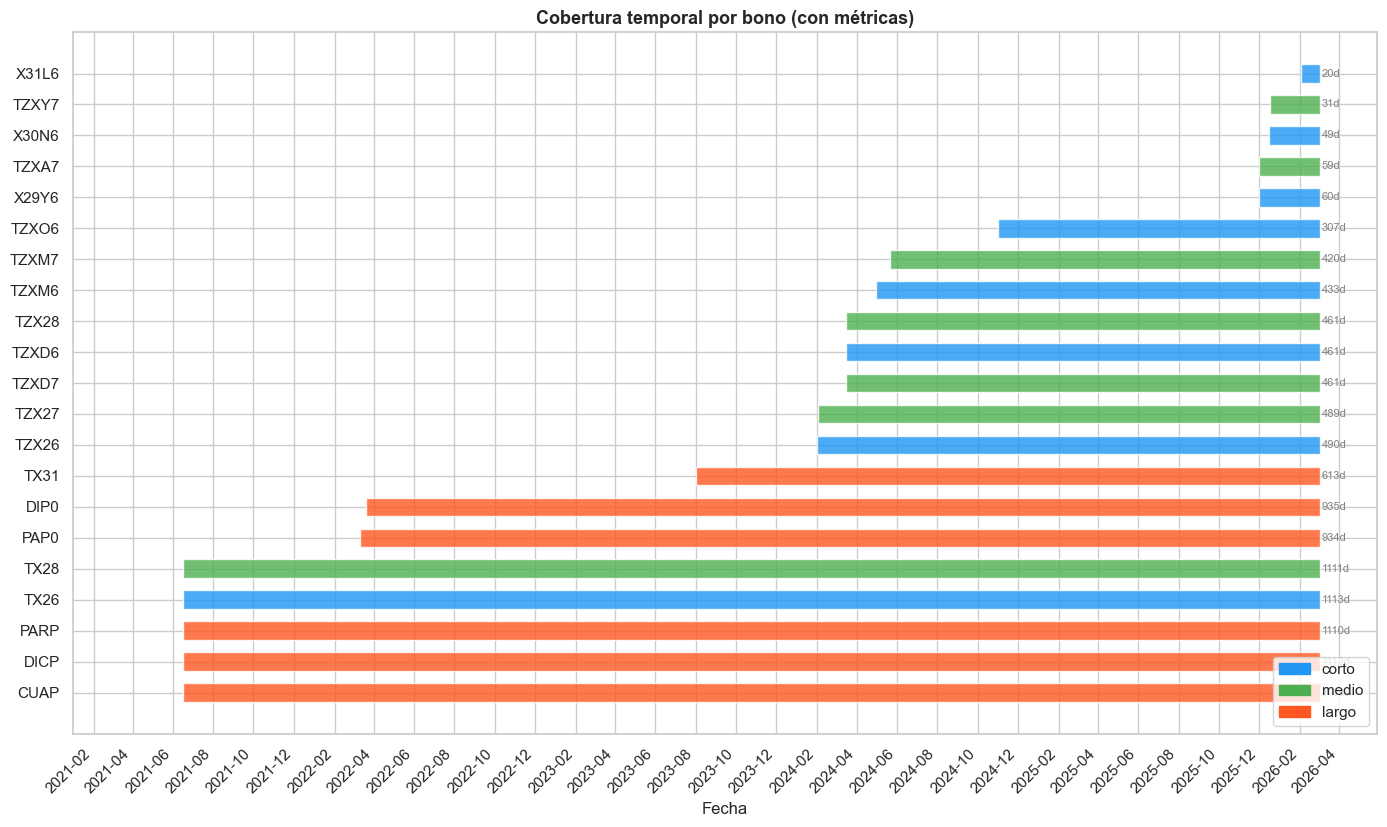

In [409]:
# Gráfico de Gantt: cobertura temporal por bono
fig, ax = plt.subplots(figsize=(14, max(6, len(cobertura) * 0.4)))

colores_grupo = {
    'corto': '#2196F3',
    'medio': '#4CAF50',
    'largo': '#FF5722',
}

for i, row in cobertura.iterrows():
    grupo = bonos_df.loc[bonos_df['ticker'] == row['ticker'], 'grupo'].values
    color = colores_grupo.get(grupo[0] if len(grupo) > 0 else 'otro', '#9E9E9E')
    ax.barh(
        y=row['ticker'],
        width=(pd.Timestamp(row['hasta']) - pd.Timestamp(row['desde'])).days,
        left=pd.Timestamp(row['desde']),
        color=color,
        alpha=0.8,
        edgecolor='white',
        height=0.6
    )
    ax.text(
        pd.Timestamp(row['hasta']) + pd.Timedelta(days=2),
        row['ticker'],
        f"{row['dias']}d",
        va='center', fontsize=8, color='gray'
    )

from matplotlib.patches import Patch
leyenda = [Patch(color=c, label=g) for g, c in colores_grupo.items()]
ax.legend(handles=leyenda, loc='lower right')
ax.set_xlim(left=pd.Timestamp(FECHA_INICIO_CER))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
ax.set_xlabel('Fecha')
ax.set_title('Cobertura temporal por bono (con métricas)', fontsize=13, fontweight='bold')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 4. Evolución histórica de yields (TIR) reales

La TIR de un bono CER es la tasa real implícita en el precio de mercado. Refleja el retorno real esperado si se mantiene el bono hasta el vencimiento.

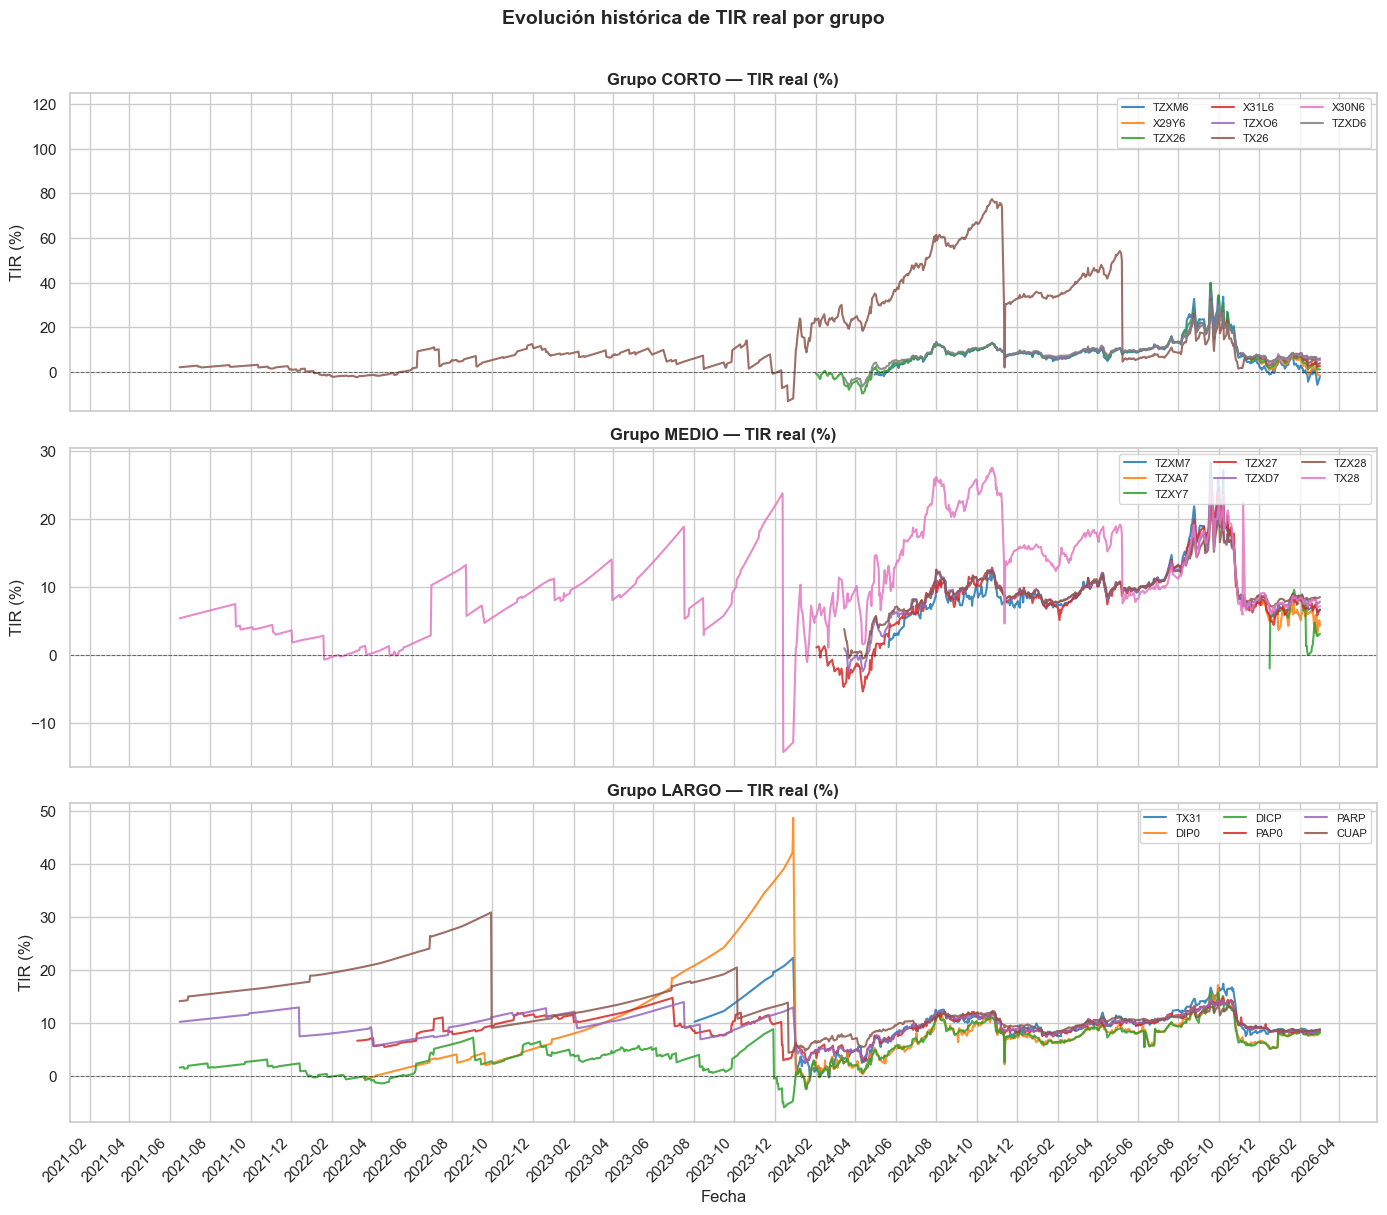

In [410]:
# TIR en porcentaje
metricas_df['tir_pct'] = metricas_df['tir'].astype(float) * 100

grupos_orden = ['corto', 'medio', 'largo']
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

for ax, grupo in zip(axes, grupos_orden):
    tickers_grupo = bonos_df.loc[bonos_df['grupo'] == grupo, 'ticker'].tolist()
    datos_grupo = metricas_df[metricas_df['ticker'].isin(tickers_grupo)]

    for ticker in tickers_grupo:
        serie = datos_grupo[datos_grupo['ticker'] == ticker].set_index('fecha')['tir_pct']
        if not serie.empty:
            ax.plot(serie.index, serie.values, label=ticker, linewidth=1.5, alpha=0.85)

    ax.set_title(f'Grupo {grupo.upper()} — TIR real (%)', fontweight='bold')
    ax.set_ylabel('TIR (%)')
    ax.legend(loc='upper right', fontsize=8, ncol=3)
    ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.5)

axes[-1].set_xlim(left=pd.Timestamp(FECHA_INICIO_CER))
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[-1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(axes[-1].get_xticklabels(), rotation=45, ha='right')
plt.xlabel('Fecha')
plt.suptitle('Evolución histórica de TIR real por grupo', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()

axes[0].set_ylim(top=125)

plt.show()

## 5. Distribución de durations y volúmenes

In [411]:
# Snapshot del último día disponible
ultimo_dia = metricas_df['fecha'].max()
snapshot = metricas_df[metricas_df['fecha'] == ultimo_dia].copy()
snapshot['duration_modificada'] = snapshot['duration_modificada'].astype(float)
snapshot['volumen'] = snapshot['volumen'].astype(float)

print(f"Snapshot al {ultimo_dia.date()} — {len(snapshot)} bonos con métricas")
snapshot[['ticker', 'grupo', 'tir_pct', 'duration_modificada', 'volumen', 'paridad']].sort_values('duration_modificada')

Snapshot al 2026-03-03 — 21 bonos con métricas


,ticker,grupo,tir_pct,duration_modificada,volumen,paridad
11775,TZXM6,corto,-2.070480,0.078334,5.233338e+10,100.1606
11779,X29Y6,corto,-1.677874,0.242424,3.087362e+10,100.4041
11769,TZX26,corto,1.204383,0.322148,1.444712e+10,99.6104
11781,X31L6,corto,2.782966,0.399832,9.800125e+09,98.8783
11766,TX26,corto,4.000074,0.417974,7.070320e+08,99.7754
11777,TZXO6,corto,5.445942,0.626173,9.920637e+09,96.5593
11780,X30N6,corto,5.508987,0.706296,3.915550e+09,96.0826
11773,TZXD6,corto,6.158415,0.740687,1.032178e+10,95.4096
11776,TZXM7,medio,6.693342,1.009165,5.961304e+09,93.2619
11772,TZXA7,medio,4.310615,1.111013,1.632612e+06,95.2268


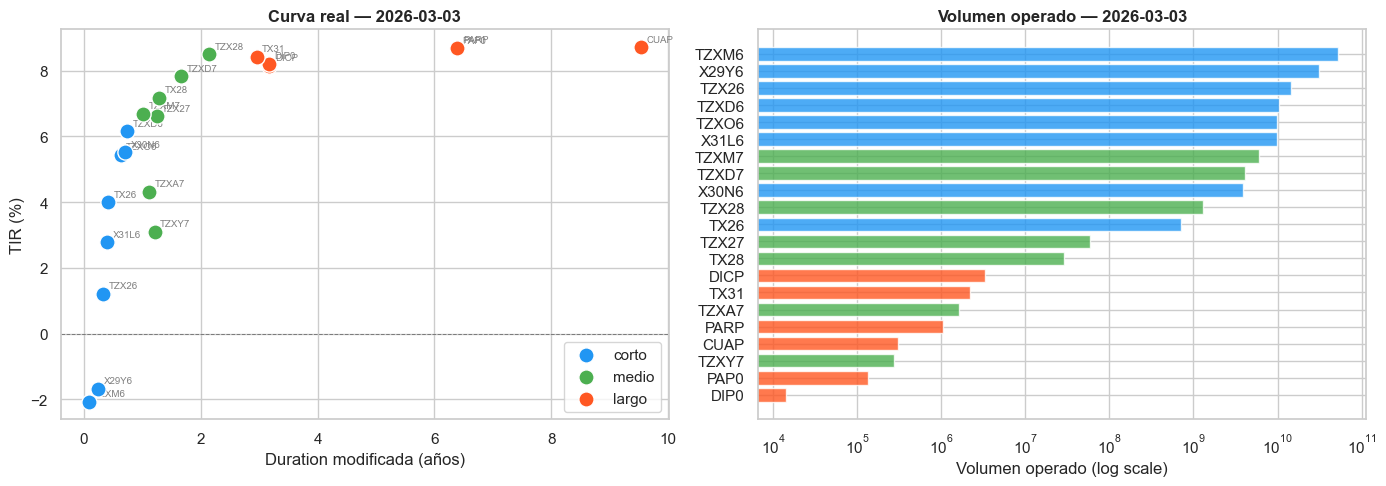

In [412]:
# Distribución de durations por grupo
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: duration vs TIR (el corazón del análisis)
colores = {'corto': '#2196F3', 'medio': '#4CAF50', 'largo': '#FF5722'}
for grupo in grupos_orden:
    d = snapshot[snapshot['grupo'] == grupo]
    ax1.scatter(
        d['duration_modificada'], d['tir_pct'],
        label=grupo, color=colores[grupo], s=120, zorder=5, edgecolors='white'
    )
    for _, row in d.iterrows():
        ax1.annotate(
            row['ticker'],
            (row['duration_modificada'], row['tir_pct']),
            textcoords='offset points', xytext=(4, 4), fontsize=7, color='gray'
        )

ax1.set_xlabel('Duration modificada (años)')
ax1.set_ylabel('TIR (%)')
ax1.set_title(f'Curva real — {ultimo_dia.date()}', fontweight='bold')
ax1.legend()
ax1.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)

# Volumen operado (log scale para que se vean todos)
snapshot_sorted = snapshot.sort_values('volumen', ascending=True)
bars = ax2.barh(
    snapshot_sorted['ticker'],
    snapshot_sorted['volumen'],
    color=[colores.get(g, '#9E9E9E') for g in snapshot_sorted['grupo']],
    alpha=0.8
)
ax2.set_xscale('log')
ax2.set_xlabel('Volumen operado (log scale)')
ax2.set_title(f'Volumen operado — {ultimo_dia.date()}', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Curva real en distintas fechas históricas

Visualizamos cómo cambió la curva (duration vs yield) a lo largo del tiempo. Ayuda a identificar momentos de estrés donde la curva tomó formas inusuales (invertida, con joroba, etc.).

In [413]:
# Seleccionar fechas de corte para comparar
fechas_disponibles = sorted(metricas_df['fecha'].unique())

# Tomar un corte mensual (primer día hábil de cada mes)
metricas_df['anio_mes'] = metricas_df['fecha'].dt.to_period('M')
primer_dia_por_mes = (
    metricas_df.groupby('anio_mes')['fecha']
    .min()
    .reset_index()['fecha']
    .tolist()
)

print(f"Meses disponibles: {[str(d.date()) for d in primer_dia_por_mes]}")

Meses disponibles: ['2021-06-16', '2021-07-01', '2021-08-02', '2021-09-01', '2021-10-01', '2021-11-01', '2021-12-01', '2022-01-04', '2022-02-01', '2022-03-02', '2022-04-01', '2022-05-02', '2022-06-01', '2022-07-01', '2022-08-01', '2022-09-01', '2022-10-03', '2022-11-01', '2022-12-02', '2023-01-02', '2023-02-01', '2023-03-01', '2023-04-03', '2023-05-02', '2023-06-01', '2023-07-03', '2023-08-01', '2023-09-01', '2023-10-02', '2023-11-01', '2023-12-01', '2024-01-02', '2024-02-01', '2024-03-01', '2024-04-03', '2024-05-02', '2024-06-03', '2024-07-01', '2024-08-01', '2024-09-02', '2024-10-01', '2024-11-01', '2024-12-02', '2025-01-02', '2025-02-03', '2025-03-05', '2025-04-01', '2025-05-05', '2025-06-02', '2025-07-01', '2025-08-01', '2025-09-01', '2025-10-01', '2025-11-03', '2025-12-01', '2026-01-02', '2026-02-02', '2026-03-02']


/var/folders/08/d9lc80m178b9xt2byjmp37sw0000gn/T/ipykernel_16880/613091347.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('RdYlGn', n_fechas)  # verde=reciente, rojo=antiguo


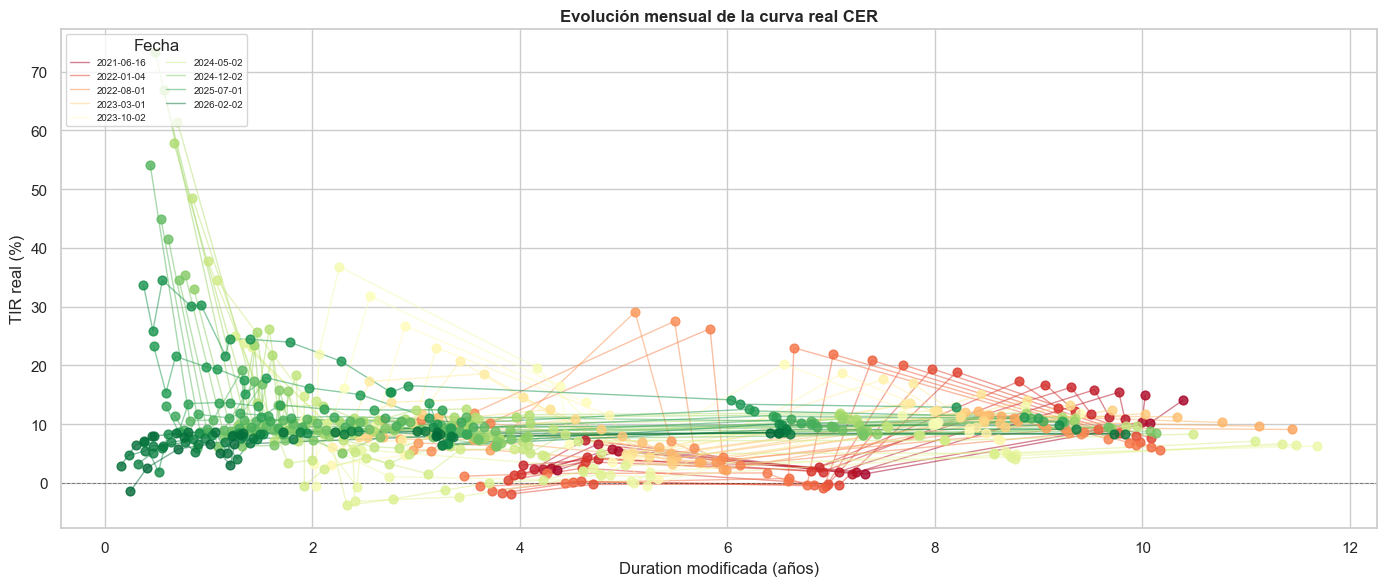

In [414]:
# Evolución de la curva mes a mes
n_fechas = len(primer_dia_por_mes)
cmap = plt.cm.get_cmap('RdYlGn', n_fechas)  # verde=reciente, rojo=antiguo

fig, ax = plt.subplots(figsize=(14, 6))

for idx, fecha in enumerate(primer_dia_por_mes):
    corte = metricas_df[metricas_df['fecha'] == fecha].copy()
    corte = corte.dropna(subset=['duration_modificada', 'tir_pct'])
    corte = corte.sort_values('duration_modificada')
    if len(corte) < 3:
        continue
    color = cmap(idx / max(n_fechas - 1, 1))
    ax.scatter(corte['duration_modificada'].astype(float), corte['tir_pct'],
               color=color, s=40, alpha=0.8, zorder=4)
    ax.plot(corte['duration_modificada'].astype(float), corte['tir_pct'],
            color=color, linewidth=1, alpha=0.5,
            label=str(fecha.date()))

ax.axhline(0, color='black', linewidth=0.7, linestyle='--', alpha=0.4)
ax.set_xlabel('Duration modificada (años)')
ax.set_ylabel('TIR real (%)')
ax.set_title('Evolución mensual de la curva real CER', fontweight='bold')

# Leyenda compacta
handles, labels = ax.get_legend_handles_labels()
if len(handles) > 12:
    step = len(handles) // 8
    handles = handles[::step]
    labels = labels[::step]
ax.legend(handles, labels, loc='upper left', fontsize=7, title='Fecha', ncol=2)

plt.tight_layout()
plt.show()

## 7. Coeficiente CER: evolución y variación mensual

El CER es el índice de inflación que ajusta el capital y cupones. Su tasa de variación mensual es la inflación implícita que afecta los flujos de los bonos.

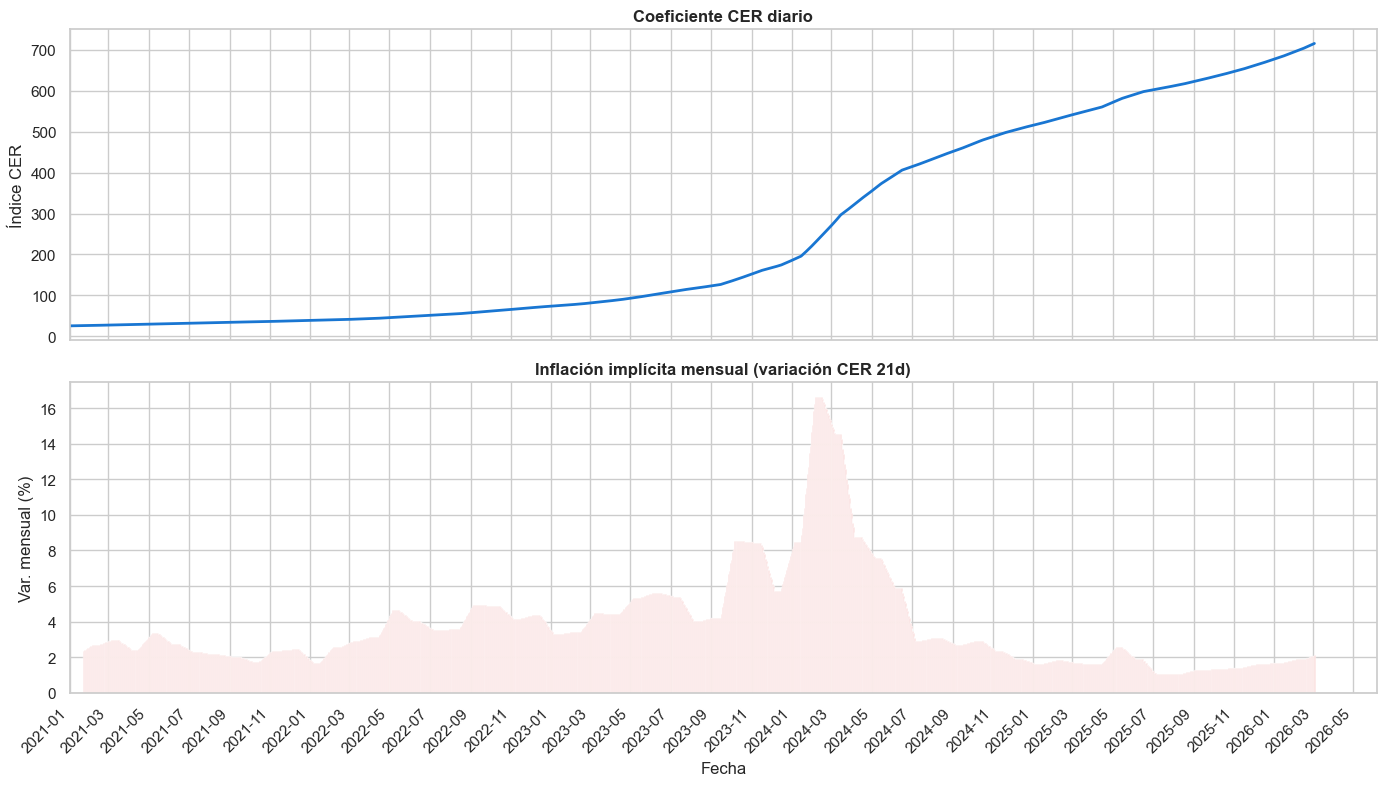

Inflación mensual promedio en el período: 3.83%
Inflación mensual máx: 16.63%
Inflación mensual mín: 1.05%


In [415]:
cer_df = cer_df.sort_values('fecha').reset_index(drop=True)
cer_df['cer'] = cer_df['cer'].astype(float)

# Variación mensual del CER (inflación implícita)
cer_df['var_mensual'] = cer_df['cer'].pct_change(periods=21) * 100  # ~21 días hábiles

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

ax1.plot(cer_df['fecha'], cer_df['cer'], color='#1976D2', linewidth=2)
ax1.set_ylabel('Índice CER')
ax1.set_title('Coeficiente CER diario', fontweight='bold')

ax2.bar(cer_df['fecha'], cer_df['var_mensual'],
        color=cer_df['var_mensual'].apply(lambda x: '#E53935' if x > 0 else '#43A047'),
        alpha=0.7, width=1)
ax2.set_ylabel('Var. mensual (%)')
ax2.set_title('Inflación implícita mensual (variación CER 21d)', fontweight='bold')
ax2.axhline(0, color='black', linewidth=0.5)

ax2.set_xlim(left=pd.Timestamp(FECHA_INICIO_CER))
ax2.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')
plt.xlabel('Fecha')
plt.tight_layout()
plt.show()

print(f"Inflación mensual promedio en el período: {cer_df['var_mensual'].mean():.2f}%")
print(f"Inflación mensual máx: {cer_df['var_mensual'].max():.2f}%")
print(f"Inflación mensual mín: {cer_df['var_mensual'].min():.2f}%")

## 8. Correlación yields reales vs inflación CER

¿Cuándo la inflación sube, las tasas reales suben o bajan? Esta relación captura el apetito del mercado por activos reales.

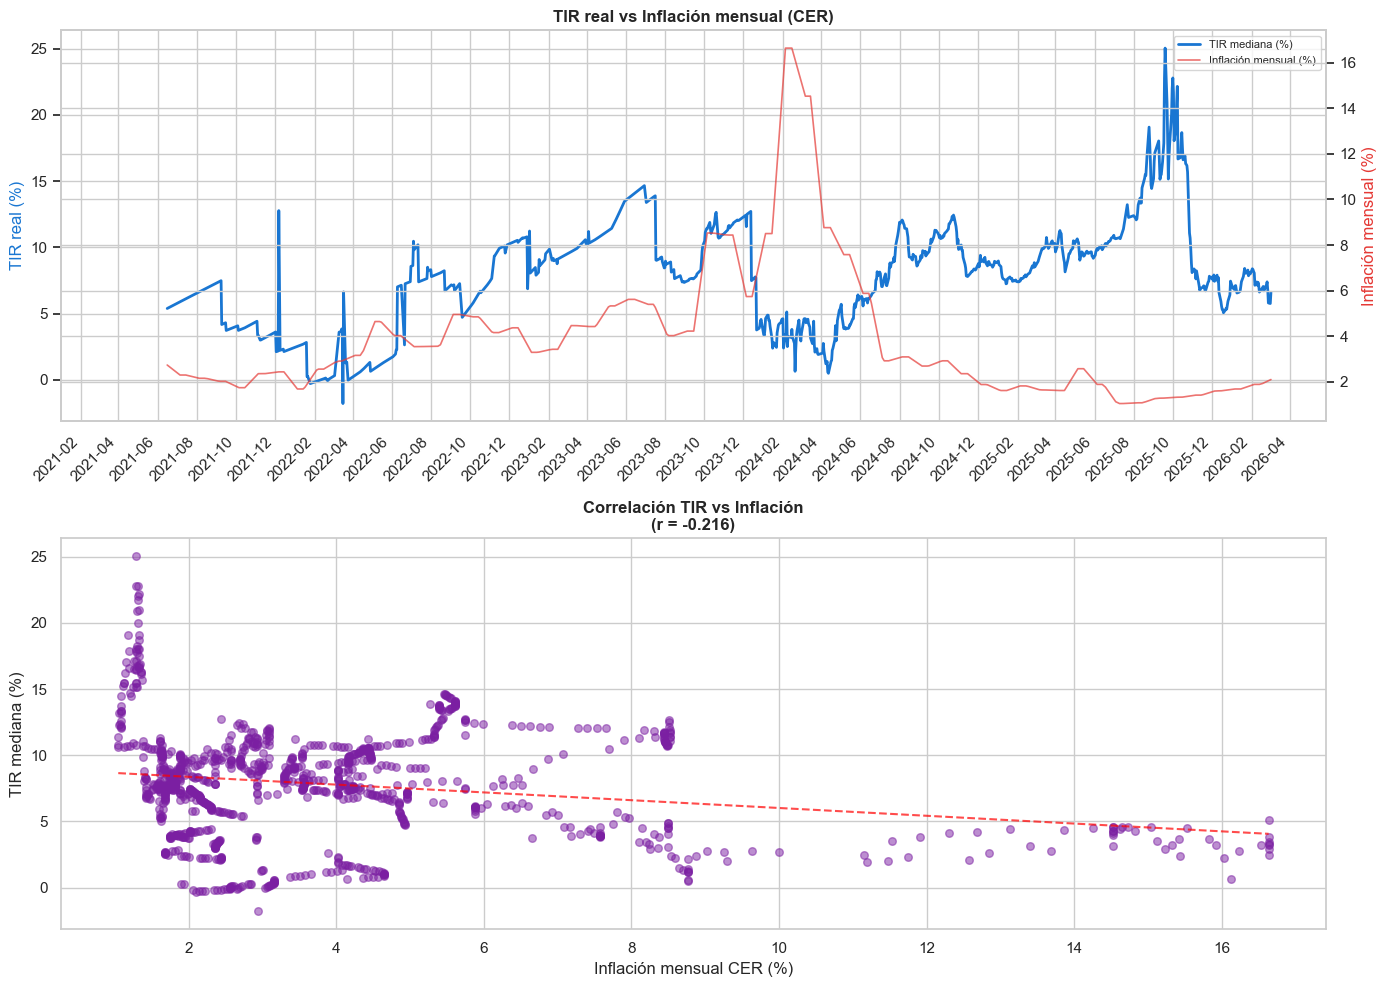

Correlación TIR mediana vs inflación mensual CER: -0.2161


In [416]:
# TIR promedio diaria del universo (proxy de la tasa real de mercado)
tir_promedio = (
    metricas_df.groupby('fecha')['tir_pct']
    .median()
    .reset_index()
    .rename(columns={'tir_pct': 'tir_mediana'})
)

# Merge con CER
merged = tir_promedio.merge(cer_df[['fecha', 'cer', 'var_mensual']], on='fecha', how='inner')
merged = merged.dropna()

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Serie temporal superpuesta
ax = axes[0]
ax2_twin = ax.twinx()
ax.plot(merged['fecha'], merged['tir_mediana'], color='#1976D2', linewidth=2, label='TIR mediana (%)')
ax2_twin.plot(merged['fecha'], merged['var_mensual'], color='#E53935', linewidth=1.2,
              alpha=0.7, label='Inflación mensual (%)')
ax.set_ylabel('TIR real (%)', color='#1976D2')
ax2_twin.set_ylabel('Inflación mensual (%)', color='#E53935')
ax.set_title('TIR real vs Inflación mensual (CER)', fontweight='bold')
ax.set_xlim(left=pd.Timestamp(FECHA_INICIO_CER))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2_twin.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=8)

# Scatter correlación
axes[1].scatter(merged['var_mensual'], merged['tir_mediana'],
                alpha=0.5, s=30, color='#7B1FA2')
corr = merged['var_mensual'].corr(merged['tir_mediana'])
axes[1].set_xlabel('Inflación mensual CER (%)')
axes[1].set_ylabel('TIR mediana (%)')
axes[1].set_title(f'Correlación TIR vs Inflación\n(r = {corr:.3f})', fontweight='bold')

# Línea de tendencia
z = np.polyfit(merged['var_mensual'].dropna(), merged['tir_mediana'].dropna(), 1)
p = np.poly1d(z)
x_line = np.linspace(merged['var_mensual'].min(), merged['var_mensual'].max(), 100)
axes[1].plot(x_line, p(x_line), 'r--', linewidth=1.5, alpha=0.7)

plt.tight_layout()
plt.show()

print(f"Correlación TIR mediana vs inflación mensual CER: {corr:.4f}")

## 9. Heatmap de TIR por bono y fecha

Vista compacta de la evolución de todas las yields simultáneamente. Permite detectar visualmente momentos de dislocation.

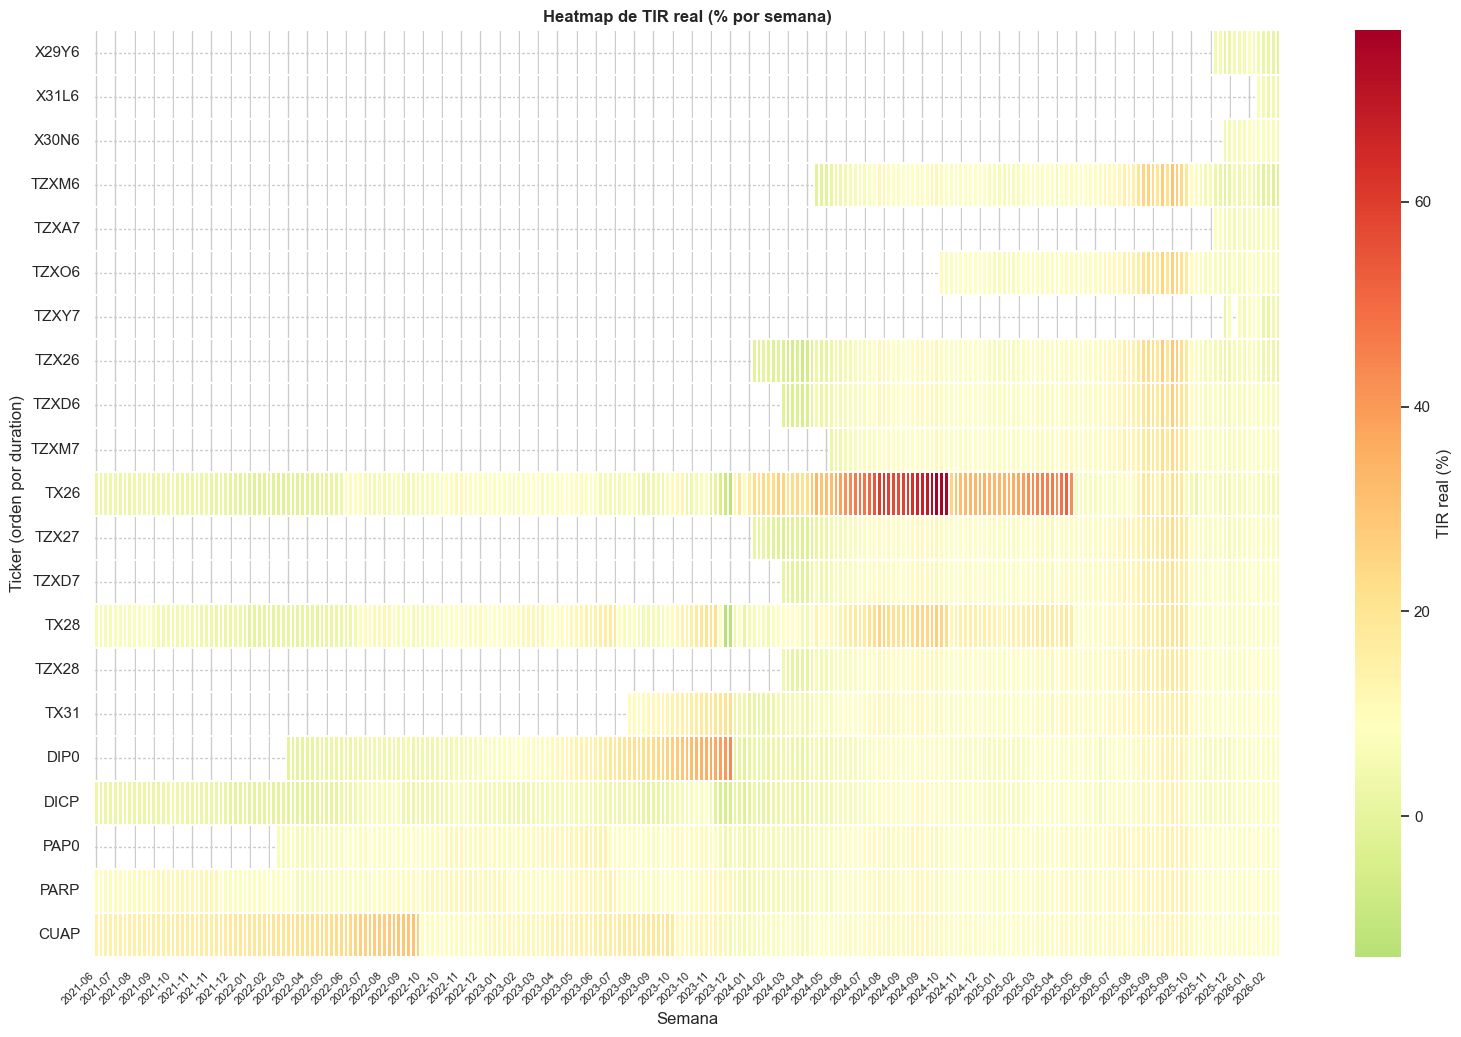

In [417]:
# Tabla pivote: filas = ticker, columnas = fecha (semanal)
metricas_df['semana'] = metricas_df['fecha'].dt.to_period('W').dt.start_time

tir_pivot = (
    metricas_df.groupby(['ticker', 'semana'])['tir_pct']
    .mean()
    .unstack('semana')
)

# Ordenar por duration promedio para que el heatmap muestre la curva de abajo a arriba
duration_promedio = metricas_df.groupby('ticker')['duration_modificada'].mean().astype(float)
tir_pivot = tir_pivot.loc[duration_promedio.sort_values().index]

fig, ax = plt.subplots(figsize=(16, max(6, len(tir_pivot) * 0.5)))
sns.heatmap(
    tir_pivot,
    ax=ax,
    cmap='RdYlGn_r',
    center=tir_pivot.stack().median(),
    fmt='.1f',
    linewidths=0.3,
    cbar_kws={'label': 'TIR real (%)'}
)

# Formatear etiquetas de columnas
ax.set_xticklabels(
    [str(pd.Timestamp(t.get_text()).date())[:7] for t in ax.get_xticklabels()],
    rotation=45, ha='right', fontsize=8
)
ax.set_xlabel('Semana')
ax.set_ylabel('Ticker (orden por duration)')
ax.set_title('Heatmap de TIR real (% por semana)', fontweight='bold')
plt.tight_layout()
plt.show()

## 10. Estadísticas descriptivas por grupo

Resumen numérico del universo para dimensionar dispersión y outliers.

In [418]:
stats = (
    metricas_df.groupby('grupo')[['tir_pct', 'duration_modificada', 'volumen', 'paridad']]
    .agg(['mean', 'std', 'min', 'max'])
)
stats.columns = ['_'.join(c) for c in stats.columns]
stats = stats.round(4)
stats

,tir_pct_mean,tir_pct_std,tir_pct_min,tir_pct_max,duration_modificada_mean,duration_modificada_std,duration_modificada_min,duration_modificada_max,volumen_mean,volumen_std,volumen_min,volumen_max,paridad_mean,paridad_std,paridad_min,paridad_max
grupo,,,,,,,,,,,,,,,,
corto,11.3935,13.1511,-13.0306,77.3797,1.5341,1.0024,0.0783,4.3562,2.833292e+09,6.027221e+09,0.0,8.386488e+10,89.0392,10.6840,56.7222,136.6093
largo,9.3720,5.5965,-5.9844,48.6552,6.5897,2.3637,1.7742,12.4927,8.734207e+05,8.755144e+06,0.0,5.965272e+08,68.9119,29.7851,8.8539,181.2701
medio,9.4373,5.5240,-14.3005,28.3007,2.5151,0.9672,1.0092,4.9459,8.646723e+08,2.073348e+09,0.0,2.597036e+10,82.1250,10.9592,57.5220,167.4246


/var/folders/08/d9lc80m178b9xt2byjmp37sw0000gn/T/ipykernel_16880/1165735714.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, labels=grupos_orden, patch_artist=True, notch=True)
/var/folders/08/d9lc80m178b9xt2byjmp37sw0000gn/T/ipykernel_16880/1165735714.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, labels=grupos_orden, patch_artist=True, notch=True)
/var/folders/08/d9lc80m178b9xt2byjmp37sw0000gn/T/ipykernel_16880/1165735714.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_plot, labels=grupos_orden, patch_artist=True, notch=True)


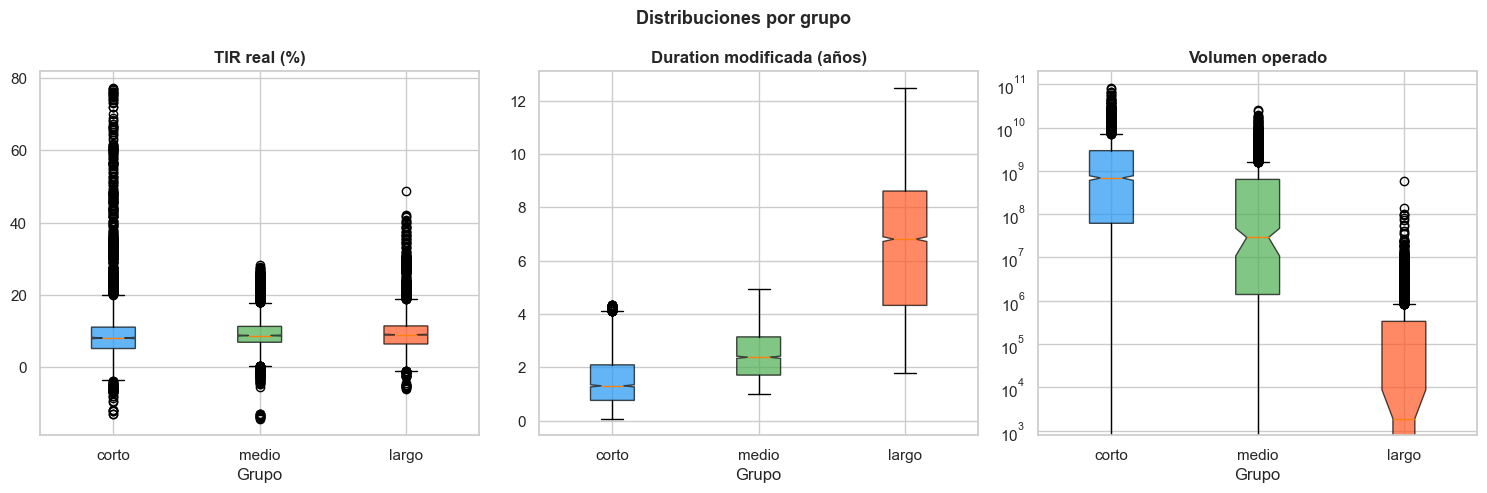

In [419]:
# Boxplots de TIR por grupo
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

variables = [
    ('tir_pct', 'TIR real (%)'),
    ('duration_modificada', 'Duration modificada (años)'),
    ('volumen', 'Volumen operado')
]

for ax, (col, label) in zip(axes, variables):
    data_plot = [
        metricas_df.loc[metricas_df['grupo'] == g, col].astype(float).dropna().values
        for g in grupos_orden
    ]
    bp = ax.boxplot(data_plot, labels=grupos_orden, patch_artist=True, notch=True)
    for patch, grupo in zip(bp['boxes'], grupos_orden):
        patch.set_facecolor(colores.get(grupo, '#9E9E9E'))
        patch.set_alpha(0.7)
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel('Grupo')
    if col == 'volumen':
        ax.set_yscale('log')

plt.suptitle('Distribuciones por grupo', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()